# 03. Tranh chấp cung và biến ẩn: thí nghiệm và dữ liệu quan sát lệch bao nhiêu

Trên thị trường gọi xe, voucher cho rider này làm rider khác chờ lâu hơn, vì hai người tranh nhau cùng một đội xe. Giả định SUTVA (kết cục của một đơn vị không phụ thuộc phân nhóm của đơn vị khác) vì vậy vỡ. Simulator cho ta **đáp án đúng** để đo xem mỗi cách ước lượng lệch bao nhiêu:

1. Hiệu ứng toàn hệ thật (GTE): bật voucher cho tất cả so với tắt cho tất cả, không ngân sách.
2. Bốn thiết kế thí nghiệm ước lượng GTE lệch bao nhiêu: A/B theo rider, switchback cụm 1 ô, 7 ô, toàn hệ (T5.3).
3. Carryover giữa các block của switchback (burn-in).
4. Dữ liệu quan sát từ chính sách cũ: chệch do biến ẩn `u_latent`, theo mức chính sách cũ nhắm vào biến ẩn (T5.3).

Chủ notebook: Tình (T6.3, H-27). Phép tính trong `analysis/interference.py` (`tests/test_policy_eval.py`). Notebook 05 (Hoàng) bàn tiếp vì sao DR-learner không gỡ được phần chệch do `u_latent`.

**Dữ liệu cần** (lệnh sinh lại ở `docs/datasets.md`, mục B7a và S5):

| Thư mục | Nội dung |
|---|---|
| `runs/b7a/gte` | all_on và all_off không ngân sách, 10 seed: GTE thật |
| `runs/b7a/rider_ab_28d`, `runs/b7a/switchback_c1_28d`, `runs/b7a/switchback_c7_28d`, `runs/b7a/switchback_all_28d` | thí nghiệm 28 ngày, p_on = 0,5, block 60 phút |
| `runs/b7a/legacy_28d`, `runs/s5/legacy_gu_0_28d`, `runs/s5/legacy_gu_0p5_28d`, `runs/s5/legacy_gu_2_28d` | chính sách cũ 28 ngày, `target_g_u` = 1 (mặc định); 0; 0,5; 2 |

Các bước có bootstrap 500 lần (thiết kế) và 200 lần (biến ẩn) theo đơn vị ngẫu nhiên hóa, seed cố định, nên số trùng với lệnh dòng lệnh `python -m analysis.interference`. Cả notebook chạy vài phút.

In [1]:
from analysis.notebook import require_runs, setup
from analysis.plots import save_figure

plt = setup()   # repository root, shared plot style, wide pandas display
DESIGNS = ["rider_ab_28d", "switchback_c1_28d", "switchback_c7_28d", "switchback_all_28d"]
LEGACY = ["runs/s5/legacy_gu_0_28d", "runs/s5/legacy_gu_0p5_28d", "runs/b7a/legacy_28d", "runs/s5/legacy_gu_2_28d"]
gte_dir, *rest = require_runs("runs/b7a/gte", *[f"runs/b7a/{d}" for d in DESIGNS], *LEGACY)
design_dirs, legacy_dirs = rest[:len(DESIGNS)], rest[len(DESIGNS):]

In [2]:
import pandas as pd
from IPython.display import display

from analysis import figures
from analysis.interference import confounding_table, design_effect, design_table, gte_truth

## 1. Hiệu ứng toàn hệ thật (GTE)

GTE = N(all_on) − N(all_off), cả hai không ngân sách, ghép cặp theo seed (CRN). Đây là đáp án mà mọi thiết kế thí nghiệm cố gắng ước lượng. Với kết cục `requested` (số request), GTE đo phần voucher kéo thêm lượt đặt.

In [3]:
truth = pd.DataFrame({outcome: gte_truth(gte_dir, outcome=outcome) for outcome in ("completed", "requested")}).T
truth.round(1)

,GTE,GTE_se,n_seeds,N_off,N_on
completed,1212.9,14.2,10.0,3439.6,4652.5
requested,1534.1,12.2,10.0,3644.2,5178.3


## 2. Mỗi thiết kế thí nghiệm ước lượng GTE lệch bao nhiêu

Mỗi bộ dữ liệu ngẫu nhiên hóa cho ra con số mà một nhóm phân tích sẽ báo cáo: hiệu tỷ lệ kết cục mỗi session (có voucher trừ không) nhân số session mỗi ngày, tức "nếu bật cho mọi session". Khoảng tin cậy bootstrap theo đơn vị ngẫu nhiên hóa: rider với A/B theo rider, (cụm, block) với switchback (H-19a). Session trong phút burn-in đầu block của switchback bị bỏ khỏi phép hiệu (Hu & Wager 2022).

In [4]:
designs = design_table(design_dirs, gte_dir, outcome="completed")
display(designs[["design", "n_units", "per_day", "ci_lo", "ci_hi", "GTE", "bias", "bias_pct"]].round(1))

,design,n_units,per_day,ci_lo,ci_hi,GTE,bias,bias_pct
0,rider_ab,19943,1646.9,1520.8,1760.5,1212.9,434.0,35.8
1,cluster_switchback cụm 1,24701,1631.6,1568.1,1690.4,1212.9,418.7,34.5
2,cluster_switchback cụm 7,4704,1496.6,1404.8,1586.0,1212.9,283.7,23.4
3,cluster_switchback cụm all,672,1267.1,1055.3,1456.8,1212.9,54.2,4.5


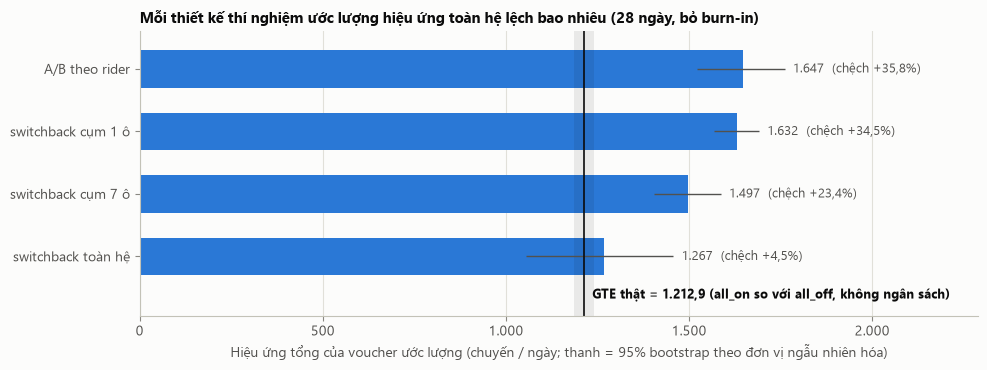

In [5]:
fig = figures.design_bias_figure(designs)
save_figure(fig, "03_chech_thiet_ke")
plt.show()

In [6]:
designs_req = design_table(design_dirs, gte_dir, outcome="requested")
designs_req[["design", "per_day", "ci_lo", "ci_hi", "GTE", "bias", "bias_pct"]].round(1)

,design,per_day,ci_lo,ci_hi,GTE,bias,bias_pct
0,rider_ab,1803.6,1666.2,1935.4,1534.1,269.5,17.6
1,cluster_switchback cụm 1,1802.3,1741.6,1860.7,1534.1,268.2,17.5
2,cluster_switchback cụm 7,1711.3,1626.0,1793.3,1534.1,177.2,11.6
3,cluster_switchback cụm all,1574.0,1398.4,1737.1,1534.1,39.9,2.6


**Đọc kết quả.**

- **A/B theo rider phóng đại khoảng 36%.** Rider được voucher và rider không được voucher ở cùng ô, cùng giờ, tranh cùng một đội xe. Nhóm có voucher đặt nhiều hơn và lấy bớt xe của nhóm không có voucher, nên hiệu giữa hai nhóm lớn hơn hiệu ứng khi bật cho cả thành phố (khi đó không còn ai để lấy bớt).
- **Cụm càng lớn, chệch càng nhỏ:** cụm 1 ô +35%, cụm 7 ô +23%, toàn hệ +4,5%. Cụm nhỏ thì xe vẫn chạy qua lại giữa cụm bật và cụm tắt bên cạnh, nên tranh chấp cung vẫn rò qua biên cụm. Thứ tự này đúng như lý thuyết (§2.7 của báo cáo phương pháp) và là bằng chứng simulator có tranh chấp cung thật.
- Với `requested`, chệch nhỏ hơn (khoảng +18% đến +3%). Tranh chấp cung tác động lên chuyến hoàn thành qua hai kênh (ETA báo dài hơn làm ít người đặt, và giành xe sau khi đặt), còn lên request chỉ qua kênh ETA báo.
- Switchback toàn hệ là thiết kế duy nhất gần đúng, nhưng có ít đơn vị (672 block) nên khoảng tin cậy rộng nhất.

## 3. Carryover giữa các block (burn-in)

Trong switchback, trạng thái xe đầu block là hệ quả của block trước (xe đang chở khách của block trước, vị trí xe). Nếu không bỏ các phút đầu block, phần carryover này lẫn vào ước lượng.

In [7]:
switchback_all = design_dirs[DESIGNS.index("switchback_all_28d")]
burnin = pd.DataFrame([{**design_effect(switchback_all, exclude_burnin=flag), "exclude_burnin": flag}
                       for flag in (True, False)])
burnin["bias_pct"] = 100 * (burnin["per_day"] - truth.loc["completed", "GTE"]) / truth.loc["completed", "GTE"]
burnin[["exclude_burnin", "n_sessions", "per_day", "ci_lo", "ci_hi", "bias_pct"]].round(1)

,exclude_burnin,n_sessions,per_day,ci_lo,ci_hi,bias_pct
0,True,538741,1267.1,1055.3,1456.8,4.5
1,False,718364,1312.7,1101.7,1513.6,8.2


Bỏ burn-in giảm chệch của switchback toàn hệ khoảng một nửa (từ khoảng +8% xuống khoảng +4,5%): gần nửa chệch còn lại của thiết kế tốt nhất là carryover đầu block, không phải tranh chấp cung giữa cụm.

## 4. Dữ liệu quan sát: chệch do biến ẩn `u_latent`

Chính sách cũ (`legacy`) nhắm voucher theo một quy tắc có dùng `u_latent`, một đặc trưng rider mà dữ liệu quan sát **không** có (giống thực tế: nhân viên vận hành biết điều mà dữ liệu không ghi). `u_latent` cũng làm rider hay đặt xe hơn, nên rider được phát voucher vốn đã hay đi: so sánh "được phát" với "không được phát" phóng đại hiệu ứng. Chính sách cũ có lát explore 5% ngẫu nhiên hóa, cho đáp án không chệch trên cùng dữ liệu.

Bốn bộ legacy 28 ngày chỉ khác `target_g_u` (mức quy tắc cũ dựa vào `u_latent`), cùng tập session (cùng `run_seed`). Hai ước lượng quan sát:

- **so thô**: được phát so với không, mọi session ngoài lát explore; so với toàn bộ lát explore;
- **điều chỉnh theo X**: được phát so với không trong từng tầng (phân khúc × thập phân vị tần suất), chỉ ô đang bật khuyến mãi; so với lát explore của ô đang bật.

Phần chệch còn lại sau điều chỉnh theo X là phần do `u_latent`.

In [8]:
confounding = confounding_table(legacy_dirs)
confounding[["target_g_u", "share_offered", "naive", "explore_all", "bias_naive", "bias_naive_lo", "bias_naive_hi",
             "adjusted", "explore_on", "bias_adjusted", "bias_adjusted_lo", "bias_adjusted_hi"]].round(4)

,target_g_u,share_offered,naive,explore_all,bias_naive,bias_naive_lo,bias_naive_hi,adjusted,explore_on,bias_adjusted,bias_adjusted_lo,bias_adjusted_hi
0,0.0,0.2055,0.0608,0.0700,-0.0092,-0.0159,-0.0029,0.0682,0.0734,-0.0052,-0.0134,0.0032
1,0.5,0.2075,0.0848,0.0666,0.0182,0.0122,0.0252,0.0949,0.0739,0.0210,0.0116,0.0300
2,1.0,0.2181,0.1053,0.0695,0.0358,0.0282,0.0431,0.1170,0.0738,0.0432,0.0311,0.0533
3,2.0,0.2154,0.1224,0.0580,0.0644,0.0564,0.0720,0.1306,0.0582,0.0724,0.0608,0.0826


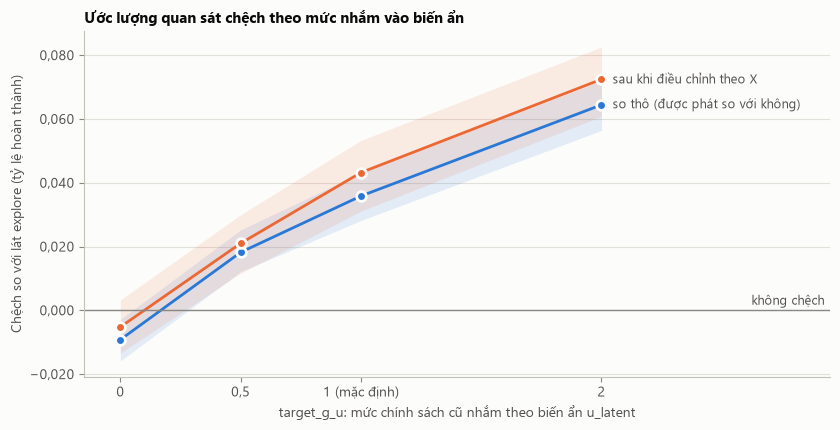

In [9]:
fig = figures.u_latent_figure(confounding)
save_figure(fig, "03_chech_u_latent")
plt.show()

**Đọc kết quả.**

- Khi quy tắc cũ **không** dựa vào biến ẩn (`target_g_u` = 0), điều chỉnh theo X là đủ: chệch còn lại không khác 0.
- Chệch tăng gần tuyến tính theo `target_g_u`. Ở mức mặc định (1), ước lượng quan sát đã điều chỉnh vẫn lớn hơn hiệu ứng thật khoảng 60% (+0,043 trên nền ≈ 0,07); ở mức 2 thì hơn gấp đôi.
- Điều chỉnh theo X **không giảm** chệch so với so thô (đường cam nằm trên đường xanh): các đặc trưng quan sát được không mang thông tin về `u_latent`. Không có biến công cụ hay lát ngẫu nhiên hóa thì không gỡ được phần này; notebook 05 cho thấy DR-learner cũng không gỡ được.

## Tóm tắt

| Nguồn sai số | Cách đo trong simulator | Độ lớn (chuyến hoàn thành) |
|---|---|---|
| Tranh chấp cung (A/B theo rider) | ước lượng thí nghiệm − GTE thật | +36% |
| Tranh chấp cung còn rò qua biên cụm | switchback cụm 1 / 7 / toàn hệ | +35% / +23% / +4,5% |
| Carryover giữa block | switchback toàn hệ, có và không burn-in | +8,2% → +4,5% khi bỏ burn-in |
| Biến ẩn `u_latent` | ước lượng quan sát đã điều chỉnh X − lát explore | 0 khi không nhắm theo biến ẩn; +60% ở mức mặc định |

Kết luận cho thực tế: muốn đo hiệu ứng của voucher trên thị trường gọi xe, cần **switchback trên vùng đủ lớn, có burn-in**; A/B theo rider thổi phồng hiệu ứng khoảng một phần ba, và dữ liệu quan sát từ chính sách cũ có thể chệch nhiều hơn thế nếu quy tắc cũ dựa vào điều dữ liệu không ghi lại. Bảng tách ba nguồn sai số đầy đủ (gây nhiễu, tranh chấp cung, năng lực) trên cùng quần thể session là việc để sau S6 (H-27).